In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
sentiment_data = pd.read_csv('/content/fear_greed_index.csv')

trader_data = pd.read_csv('/content/historical_data.csv', low_memory=False)

print(sentiment_data.head())
print(trader_data.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [4]:
sentiment_data['date'] = pd.to_datetime(sentiment_data['date'], format='%Y-%m-%d')

In [5]:
trader_data['Timestamp IST'] = pd.to_datetime(trader_data['Timestamp IST'], format='%d-%m-%Y %H:%M')
trader_data['date'] = trader_data['Timestamp IST'].dt.date

In [7]:
trader_data['date'] = pd.to_datetime(trader_data['date'])
merged_data = pd.merge(trader_data, sentiment_data[['date', 'classification']], on='date', how='left')

print(merged_data.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [9]:
# Daily PnL per trader using correct column name 'Closed PnL'
daily_pnl = merged_data.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
print("Daily PnL Head:")
print(daily_pnl.head())

# Calculate win rate
merged_data['win'] = np.where(merged_data['Closed PnL'] > 0, 1, 0)
win_rate = merged_data.groupby('Account')['win'].mean().reset_index()
print("\nWin Rate Head:")
print(win_rate.head())

# Calculate avg trade size using correct column name 'Size Tokens'
avg_trade_size = merged_data.groupby('Account')['Size Tokens'].mean().reset_index()
print("\nAvg Trade Size Head:")
print(avg_trade_size.head())

# Daily trades
trades_per_day = merged_data.groupby('date').size().reset_index(name='num_trades')
print("\nTrades Per Day Head:")
print(trades_per_day.head())

# Long/Short ratio
long_short_ratio = merged_data.groupby(['date', 'Side']).size().unstack().fillna(0).reset_index()
print("\nLong/Short Ratio Head:")
print(long_short_ratio.head())

Daily PnL Head:
                                      Account       date  Closed PnL
0  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11         0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17         0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18         0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-22    -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-26      1603.1

Win Rate Head:
                                      Account       win
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914

Avg Trade Size Head:
                                      Account   Size Tokens
0  0x083384f897ee0f19899168e3b1bec365f52a9012     16.167205
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    503.067911
2  0x271b2809742

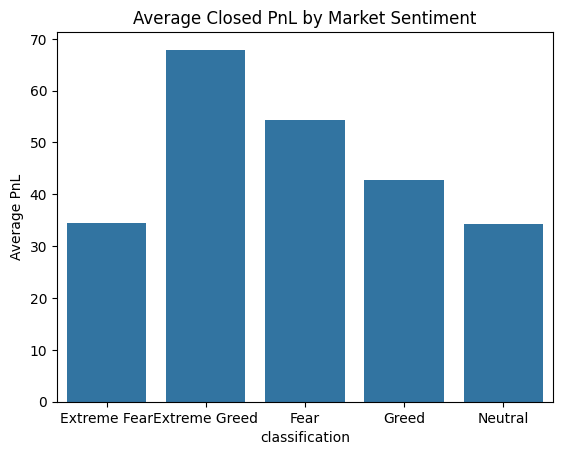

In [15]:
sentiment_pnl = merged_data.groupby('classification')['Closed PnL'].mean().reset_index()

sns.barplot(x='classification', y='Closed PnL', data=sentiment_pnl)
plt.title('Average Closed PnL by Market Sentiment')
plt.ylabel('Average PnL')
plt.show()

In [17]:
behavior_sentiment = merged_data.groupby('classification').agg({
    'Size Tokens': 'mean',
    'Closed PnL': 'mean'
}).reset_index()

print("Average metrics by Market Sentiment:")
print(behavior_sentiment)

Average metrics by Market Sentiment:
  classification  Size Tokens  Closed PnL
0   Extreme Fear  1675.893319   34.537862
1  Extreme Greed  8832.415746   67.892861
2           Fear  2992.641845   54.290400
3          Greed  4715.327756   42.743559
4        Neutral  4383.368714   34.307718


In [19]:
# Feature selection using available columns
features = merged_data[['classification', 'Size Tokens', 'Execution Price']]
features = pd.get_dummies(features, drop_first=True)

# Target: Predict whether Closed PnL is positive (1) or negative (0)
target = np.where(merged_data['Closed PnL'] > 0, 1, 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_y_pred))

Random Forest Accuracy: 0.8302047579595219


In [28]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define a smaller random parameter grid to speed up the search
param_dist = {
    'n_estimators': randint(50, 100),
    'max_depth': [10, 20],
    'min_samples_split': randint(2, 5),
    'min_samples_leaf': randint(1, 2)
}

# Set n_jobs=1 to prevent 'No space left on device' errors during parallelization
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist,
                                   n_iter=30, cv=3, n_jobs=1, verbose=2, random_state=42)

random_search.fit(X_train, y_train)

# Best parameters from RandomizedSearchCV
print("Best parameters from RandomizedSearchCV:", random_search.best_params_)

# Accuracy with the best model
best_rf_model_random = random_search.best_estimator_
rf_y_pred_random = best_rf_model_random.predict(X_test)

# Print the accuracy of the model
print("Accuracy with RandomizedSearchCV:", accuracy_score(y_test, rf_y_pred_random))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=64; total time=  11.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=64; total time=   9.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=64; total time=   8.7s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=70; total time=   9.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=70; total time=  10.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=70; total time=   9.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=3, n_estimators=68; total time=   9.7s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=3, n_estimators=68; total time=   8.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=3, n_estimators=68; total time=  11.0s
[CV] END max_depth=10, min_samples_leaf